<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DS
FP/Session-25/blob/main/Day3/Tutorial_Finetuning_IC.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg"
alt="Open In Colab"/>
</a>

# 🔭 Fine-Tuning a Language Model for Astronomy

Author: Ioana Ciucă

Companion tutorial to **Lecture 2: Large Language Models**.

## Learning Objectives

By completing this tutorial, you will:
- Measure what a small language model can do **zero-shot** on an astronomy task
- Build a labeled dataset from arXiv, at no cost
- Fine-tune the model with **LoRA** and measure the improvement

#### The Problem: teach a small language model to classify abstracts into astro-ph subfields
- **Question 1:** parse the model's answers
- **Question 2:** find where the model goes wrong
- **Question 3 (Challenge):** instruction-tune your own astronomy assistant

**Hardware:** free Colab T4 GPU (`Runtime → Change runtime type → T4 GPU`).


## Imports & Setup

In [1]:
# Install ONLY what Colab doesn't already have (run once, ~1 minute).
# Colab provides transformers, datasets etc. — leave those alone, or pip may
# break pyarrow and force a runtime restart.
%pip install -q peft trl feedparser
%pip install --upgrade torchao

# If you DO hit a pyarrow / "binary incompatibility" error anyway:
#   Runtime -> Restart session, then run the cells again (downloads are cached).
# Running locally? You need torch >= 2.7 and:
#   pip install -U torch transformers datasets peft trl feedparser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
import time
import urllib.parse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import feedparser
from tqdm.auto import tqdm

np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("No GPU detected! Switch the Colab runtime to T4 before training.")

Device: cuda


---
# The Problem

Pre-trained language models are **generalists**. Fine-tuning turns them into **specialists**. Domain models such as astroBERT (Grezes et al. 2021) were built this way.

**Our task:** read an abstract, output its astro-ph subfield — GA, CO, EP, HE, or SR. This task has two useful properties:
- The labels are easily available authors select the subfield when they submit to arXiv.
- Success is the accuracy before vs. after fine-tuning.

## 1. A small LLM, and how to talk to it

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Qwen2.5-0.5B-Instruct: a small chat model. Small = fast on a free T4.
# (Ignore any HF_TOKEN warnings during download: the model is public.)
LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    dtype=torch.float16 if device == "cuda" else torch.float32,  # half precision on GPU
).to(device)

def chat(prompt, model=llm, max_new_tokens=200):
    """Ask the model one question, get its answer as a string."""
    # 1. Wrap the prompt in the chat format the model was trained on
    messages = [{"role": "user", "content": prompt}]
    inputs = llm_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    # 2. Generate new tokens (greedy decoding — same answer every time)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=llm_tokenizer.eos_token_id,
        )
    # 3. Cut off the prompt, keep only the newly generated tokens
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return llm_tokenizer.decode(new_tokens, skip_special_tokens=True)

print(chat("In one sentence: what is a tidal disruption event?"))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

A tidal disruption event refers to an extreme weather phenomenon where the sea level rises dramatically due to heavy rainfall or snowfall, causing flooding and erosion of coastal areas.


## 2. Build a labeled dataset from arXiv (~2 minutes)

We pull recent abstracts from the [arXiv API](https://info.arxiv.org/help/api/index.html) (no key needed) and use the authors' own subfield choices as labels.

In [6]:
import urllib.request
import feedparser
import time
import random

def fetch_astro_papers(subfield, num_papers=80):
    """Fetches recent papers for a specific astro-ph subfield."""
    print(f"Fetching astro-ph.{subfield}...")
    # Request up to 200 papers to ensure we get enough 'primary' matches
    url = f"http://export.arxiv.org/api/query?search_query=cat:astro-ph.{subfield}&max_results=200&sortBy=submittedDate&sortOrder=descending"

    # Fetch and parse the XML response
    response = urllib.request.urlopen(url)
    feed = feedparser.parse(response.read())

    examples = []
    for entry in feed.entries:
        # We only want papers where this subfield is the main topic
        primary_cat = entry.arxiv_primary_category['term']
        if primary_cat == f"astro-ph.{subfield}":
            examples.append({
                "title": entry.title.replace("\n", " "), # Grab the title for Question 3
                "abstract": entry.summary.replace("\n", " "),
                "label": subfield
            })
            if len(examples) == num_papers:
                break

    time.sleep(3)  # Be nice to the arXiv API
    return examples

# The 5 astronomy subfields we are classifying
LABELS = ["GA", "CO", "EP", "HE", "SR"]

# 1. Fetch 80 papers per subfield (400 total)
all_data = []
for label in LABELS:
    all_data.extend(fetch_astro_papers(label, num_papers=80))

# 2. Shuffle the combined dataset
random.shuffle(all_data)

# 3. Split into Train (300) and Test (100)
train_data = all_data[:300]
test_data = all_data[300:]

print(f"\nDataset ready: {len(train_data)} train examples, {len(test_data)} test examples.")

Fetching astro-ph.GA...
Fetching astro-ph.CO...
Fetching astro-ph.EP...
Fetching astro-ph.HE...
Fetching astro-ph.SR...

Dataset ready: 300 train examples, 100 test examples.


## 3. Baseline: zero-shot accuracy

A fine-tuning result is only meaningful relative to the original model's score on the same test set.

In [9]:
def classify_prompt(abstract):
    """Ask the model for a two-letter subfield code."""
    return (
        "You are an arXiv moderator. Classify the following astronomy "
        "abstract into exactly one astro-ph subfield. Reply with only the "
        "two-letter code.\n\n"
        "Codes: GA (galaxies), CO (cosmology), EP (Earth and planets), "
        "HE (high energy), SR (solar and stellar).\n\n"
        f"Abstract: {abstract[:1200]}\n\nCode:"
    )

def classify(abstract, model=llm):
    # max_new_tokens=6: we only need a couple of tokens for the code
    return chat(classify_prompt(abstract), model=model, max_new_tokens=6)

# What does the raw output look like?
example = test_data[0]
print(f"True label:   {example['label']}")
print(f"Model output: {classify(example['abstract'])!r}")

True label:   SR
Model output: 'GAEP'


## Question 1: Parse the model's answers — Solution

In [12]:
def parse_label(reply):
    """Return the label code at the start of the reply, else None."""
    # ==========================================
    # STUDENT TODO:
    # 1. Extract the first two characters of the reply.
    # 2. Convert them to uppercase.
    # 3. If the code is in the LABELS list, return it. Otherwise, return None.
    # ==========================================
    label = reply.replace(" ", "")[:2]
    if label.upper() in LABELS:
        return label.upper()
    else:
      print(f"Label {label} not found in LABELS.")
      return None

# Uncomment the tests below once you implement the function!
assert parse_label("GA") == "GA"
assert parse_label(" sr ") == "SR"
assert parse_label("EP (Earth and Planetary)") == "EP"
assert parse_label("I am not sure.") is None
print("All tests passed.")


Label Ia not found in LABELS.
All tests passed.


In [13]:
def evaluate(model, dataset, desc="evaluating"):
    """Classify every abstract; return (predictions, accuracy)."""
    preds = []
    for ex in tqdm(dataset, desc=desc):
        preds.append(parse_label(classify(ex["abstract"], model=model)))
    golds = [ex["label"] for ex in dataset]
    accuracy = float(np.mean([p == g for p, g in zip(preds, golds)]))
    return preds, accuracy

# ~2 minutes on a T4
zs_preds, zs_acc = evaluate(llm, test_data, desc="zero-shot")
print(f"Zero-shot accuracy: {zs_acc:.1%} ")

zero-shot:   0%|          | 0/100 [00:00<?, ?it/s]

Zero-shot accuracy: 21.0% 


## 4. Fine-tune with LoRA

The training data is formatted as a set of conversations: our prompt as the user turn, and the true label as the assistant turn. This is called **Instruction Tuning**. By training the model on this conversational format, we teach it to behave like a helpful assistant that reliably follows commands, rather than just a text autocomplete engine.

**Why not update all the weights?** Full fine-tuning stores, for every parameter, the weight, its gradient, and two Adam optimizer states, roughly four times the model's size in memory. That exceeds a free T4 GPU even at 0.5B parameters.

**LoRA** (Low-Rank Adaptation; Hu et al. 2021) avoids this. Each chosen weight matrix $W$ (shape $d \times k$) stays frozen. We add a trainable correction:

$$W' = W + BA, \qquad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\; r \ll d$$

Only $B$ and $A$ are trained. Concretely, in our model $W_Q$ is $896 \times 896$ — about 800,000 parameters. Its rank-16 correction has $16 \times (896 + 896) \approx 29{,}000$ parameters: under 4% of the original matrix.

Three details to read in the code below:
- We attach corrections to $W_Q$, $W_K$, $W_V$, $W_O$. These are the same attention matrices you built by hand in the Lecture 1 tutorial.
- The correction is scaled by $\alpha / r$ (`lora_alpha`). $B$ is initialized to zero, so training starts exactly at the pre-trained model.
- The underlying assumption: the *change* needed to adapt a pre-trained model to one task has low rank. Empirically, this holds well.

In [14]:
from datasets import Dataset

def to_messages(example):
    return {"messages": [
        {"role": "user", "content": classify_prompt(example["abstract"])},
        {"role": "assistant", "content": example["label"]},   # the answer we want
    ]}

train_dataset = Dataset.from_list([to_messages(ex) for ex in train_data])
print(f"{len(train_dataset)} training conversations")

300 training conversations


In [15]:
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

# A fresh copy to fine-tune — keeps `llm` untouched for comparison
sft_model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME, dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

lora_config = LoraConfig(
    r=16,                    # rank of the correction matrices B and A
    lora_alpha=32,           # scaling factor (convention: 2*r)
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # W_Q, W_K, W_V, W_O
    task_type="CAUSAL_LM",
)

training_args = SFTConfig(
    output_dir="./sft_results",
    num_train_epochs=5,                # Increased to 5 so the model has time to learn
    per_device_train_batch_size=8,     # The T4 GPU can easily handle 8 for a 0.5B model
    learning_rate=2e-4,                # LoRA likes higher LRs than full FT
    logging_steps=20,
    save_strategy="no",
    report_to="none",
)

trainer = SFTTrainer(
    model=sft_model,
    args=training_args,
    train_dataset=train_dataset,
    peft_config=lora_config,           # ← this makes it LoRA, not full FT
)

trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable parameters: {trainable:,} of {total:,} ({trainable/total:.2%})")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Trainable parameters: 2,162,688 of 496,195,456 (0.44%)


In [16]:
# ~3 minutes on a T4. The loss should decrease steadily.
trainer.train()
print("Fine-tuning complete.")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
20,2.457103
40,2.022736
60,2.001402
80,1.960723
100,1.928181
120,1.937771
140,1.929785
160,1.885693
180,1.880812


Fine-tuning complete.


## 5. Evaluate the fine-tuned model

fine-tuned:   0%|          | 0/100 [00:00<?, ?it/s]

Zero-shot:  21.0%
Fine-tuned: 60.0%


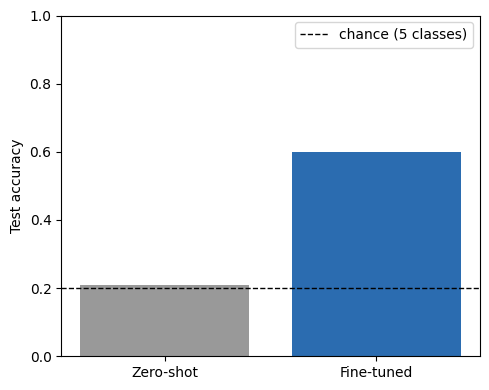

In [17]:
ft_model = trainer.model
ft_model.eval()

ft_preds, ft_acc = evaluate(ft_model, test_data, desc="fine-tuned")

print(f"Zero-shot:  {zs_acc:.1%}")
print(f"Fine-tuned: {ft_acc:.1%}")

# Before/after, with the chance level for reference
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Zero-shot", "Fine-tuned"], [zs_acc, ft_acc], color=["#999", "#2b6cb0"])
ax.axhline(0.2, ls="--", color="k", lw=1, label="chance (5 classes)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Try it out :)

Your classifier works on papers that did not exist when you opened this notebook. Go to [arxiv.org/list/astro-ph/new](https://arxiv.org/list/astro-ph/new) and paste any abstract posted today:

In [19]:
my_abstract = """
Slitless spectroscopy enables efficient, large-area surveys without target pre-selection, yet it faces challenges from source blending, higher noise, and lost spatial-spectral information. We present an advanced, non-parametric, data-driven algorithm that leverages multiple dispersion angles to reconstruct three-dimensional flux distributions, providing low-resolution Integral Field Unit (IFU) capabilities from slitless data. By treating each pixel as an independent element, our method naturally handles source confusion without requiring prior assumptions regarding redshifts, templates, or model libraries. We validate the algorithm using simulated Roman Space Telescope wide-field slitless spectroscopy images that are equivalent to what is expected from the High-Latitude Time-Domain Survey. First, we demonstrate that a host-galaxy model reconstructed from multiple dispersion angles can be used to accurately subtract host light from a transient, recovering a Type Ia supernova spectrum with minimal bias. Second, we showcase a high-fidelity flux-cube reconstruction of a complex galaxy, successfully measuring the redshift and recovering continuum, emission, and absorption features. This approach highlights the potential of multi-dispersion-angle slitless data to provide spatially resolved spectral information in a non-parametric way, which is traditionally accessible only with integral field spectroscopy, opening a new window into large, unbiased, and spatially-resolved studies of galaxy evolution.
"""

print("Predicted subfield:", parse_label(classify(my_abstract, model=ft_model)))

Predicted subfield: SR


A 0.5B model, 300 labeled abstracts, 0.2% of the parameters, a few minutes on a free GPU. Larger domain-specialized models are built the exact same way, just on a bigger scale.

### Question 4: How do we make this even better?
We only trained on 300 abstracts (60 per category). What do you think would happen to our test accuracy if we dramatically increased the dataset size?

**STUDENT TODO:**
1. Scroll back up to **Section 2**.
2. Change `num_papers=80` to something larger, like `250`.
3. Re-run the notebook (`Runtime → Run all`).
4. Observe how the training time and the final Confusion Matrix change.

*Think about the trade-off: data is cheap to fetch, but does adding more data always give you a proportional increase in accuracy? When do you hit diminishing returns?*

## Question 2: Explore your classifier — Solution

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# STUDENT TODO: Where does the model get confused?
# 1. Extract the true labels from `test_data` into a list.
# 2. Compute the confusion matrix comparing true labels to `ft_preds`.
# 3. Plot it using `sns.heatmap()`.
#
# HINTS:
# - true_labels = [ex["label"] for ex in test_data]
# - cm = confusion_matrix(true_labels, ft_preds, labels=LABELS)
# - sns.heatmap(cm, annot=True, xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
# ==========================================


In [ ]:
# ==========================================
# STUDENT TODO:
# Create a few ambiguous abstracts of your own and see how the model categorizes them!
# ==========================================
# my_sentences = [...]


## Question 3 (Challenge): Instruction-tune your own astronomy assistant — Solution

In [ ]:
# ==========================================
# STUDENT TODO: Instruction-tune your own assistant!
# 1. Fetch papers for your favorite subfield using `fetch_astro_papers(subfield)`.
# 2. Build a (question, answer) dataset mapping a question about the title to the abstract.
# 3. Train a new LoRA model on this dataset.
# 4. Test it by asking it to summarize a paper.
# ==========================================


---
# Summary

You measured a zero-shot baseline, built a labeled dataset from arXiv at no cost, trained 0.2% of the parameters with LoRA, and turned a generalist into a specialist that works on new papers.

One limitation to remember: fine-tuning does not keep up with the literature. New knowledge requires retraining. **RAG** (retrieval-augmented generation) addresses this differently. In RAG, the weights stay fixed, and relevant papers are retrieved and placed in the prompt at question time. The two approaches are complementary, and production systems use both.

## References

- Hu et al. 2021 — *LoRA: Low-Rank Adaptation of Large Language Models* ([arXiv:2106.09685](https://arxiv.org/abs/2106.09685))
- Grezes et al. 2021 — *astroBERT* ([arXiv:2112.00590](https://arxiv.org/abs/2112.00590))
- Ouyang et al. 2022 — *Training language models to follow instructions* ([arXiv:2203.02155](https://arxiv.org/abs/2203.02155))